# Inital Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# quarto preview 00_initial_eda.ipynb --to pdf
# quarto render 00_inital_eda.ipynb
# black 00_inital_eda.ipynb

sns.set(style="whitegrid", palette="pastel")

### Data Overview & Loading

In [2]:
df = pd.read_csv(
    "data/bank-full.csv", sep=";", quotechar='"', index_col=0
).reset_index()
print(df.shape)
df.head(2)

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# 'unknown' values in object columns
print("\n'unknown' values:")
for col in df.select_dtypes(include="object").columns:
    n_ = (df[col] == "unknown").sum()
    if n_ != 0:
        pct = (n_ / len(df)) * 100
        print(f"{col}: {n_} ({pct:.2f}%)")

# -1 values (common placeholder)
print("\n'-1' values:")
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    n_ = (df[col] == -1).sum()
    if n_ != 0:
        pct = (n_ / len(df)) * 100
        print(f"{col}: {n_} ({pct:.2f}%)")


'unknown' values:
job: 288 (0.64%)
education: 1857 (4.11%)
contact: 13020 (28.80%)
poutcome: 36959 (81.75%)

'-1' values:
balance: 50 (0.11%)
pdays: 36954 (81.74%)


- Loaded a banking dataset with 45,211 records and 17 features.
- Features include customer demographics (`age`, `job`, `marital`, `education`), financial information (`balance`, `loan`, `housing`), contact info (`contact`, `day`, `month`, `duration`), and campaign history (`campaign`, `pdays`, `previous`, `poutcome`).
- No missing values were found, but several columns contain `'unknown'` entries (notably `contact` 28.8%, `poutcome` 81.8%).
- Numeric columns use -1 as a placeholder in `balance` (0.11%) and `pdays` (81.74%)

### Target Variable (y) Distribution

In [5]:
# Check target distribution
print("Target distribution:")
print(df["y"].value_counts())
print("\nPercentages:")
print(df["y"].value_counts(normalize=True) * 100)

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


Highly imbalanced: 11.7% `yes`, 88.3% `no`.

### Categorical Features Insights

In [ ]:
# Check unique values for categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if "y" in categorical_cols:
    categorical_cols.remove("y")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default:
default
no     44396
yes      815
Name: count, dtype: int64

housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

- Most common `jobs`: blue-collar (9,732), management (9,458), technician (7,597).
- `Marital status`: married dominates (27,214).
- `Education`: mostly secondary (23,202) and tertiary (13,301).
- Majority have no `default` on credit (44,396) and `housing` loan is common (25,130).

### Numeric Features Summary

In [8]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[numeric_cols].describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

- Average `age`: 41 years
- Median `balance`: 448.
- Campaign metrics vary widely, e.g., `duration` max: 4,918, `campaign` max: 63.

### Numeric Features Analysis by Target (y)


age mean by target:
y
no     40.838986
yes    41.670070
Name: age, dtype: float64


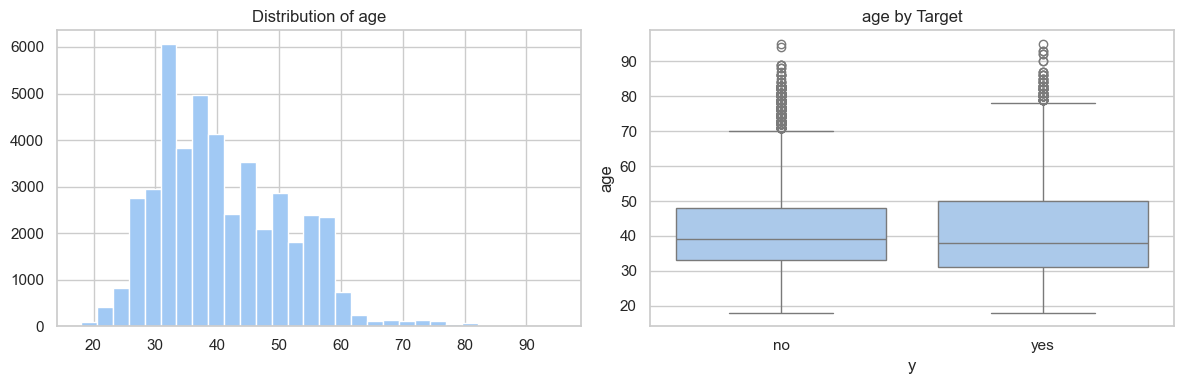


balance mean by target:
y
no     1303.714969
yes    1804.267915
Name: balance, dtype: float64


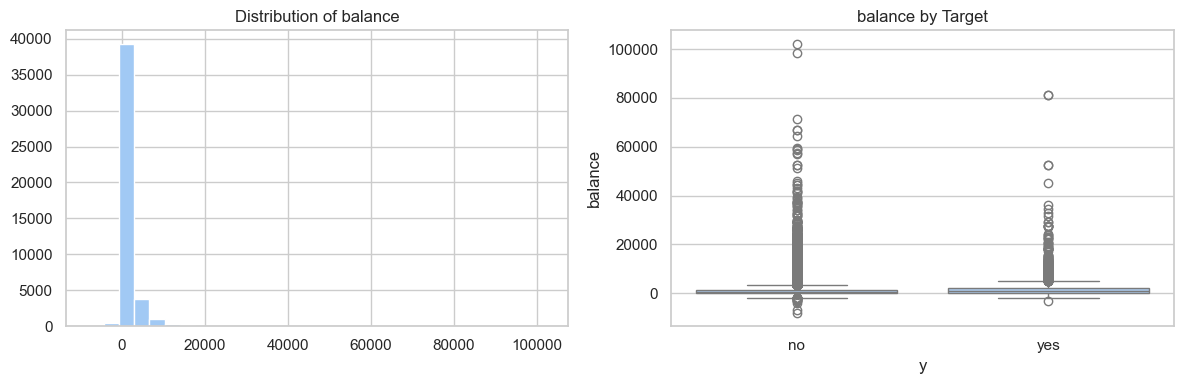


day mean by target:
y
no     15.892290
yes    15.158253
Name: day, dtype: float64


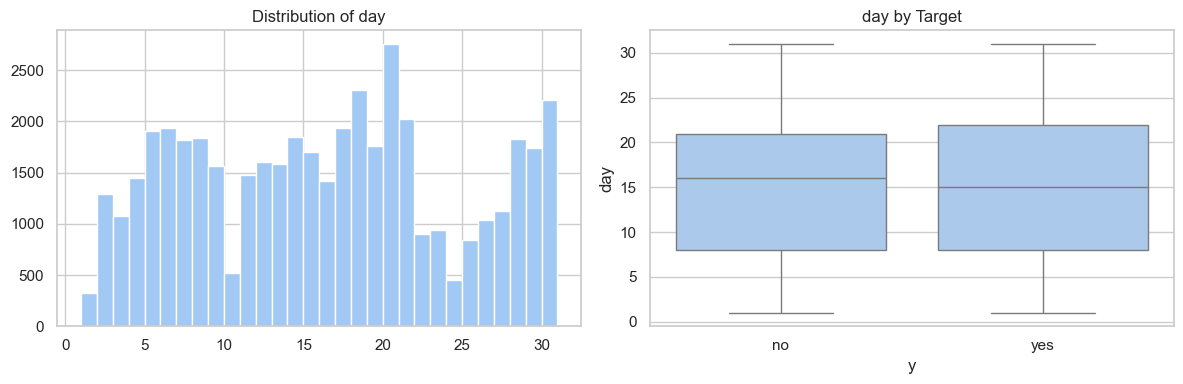


duration mean by target:
y
no     221.182806
yes    537.294574
Name: duration, dtype: float64


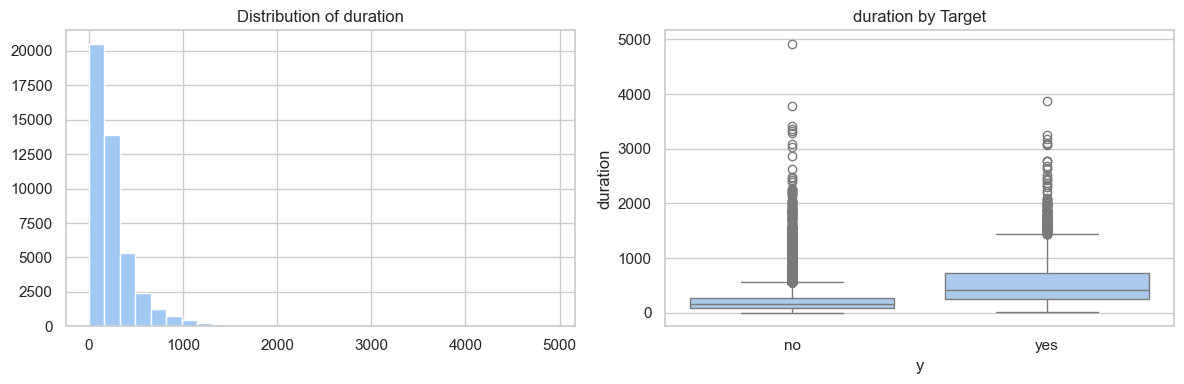


campaign mean by target:
y
no     2.846350
yes    2.141047
Name: campaign, dtype: float64


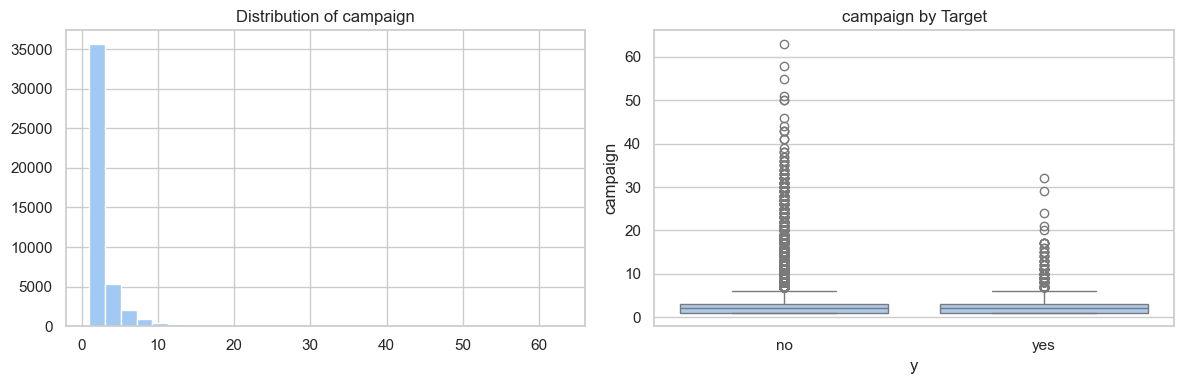


pdays mean by target:
y
no     36.421372
yes    68.702968
Name: pdays, dtype: float64


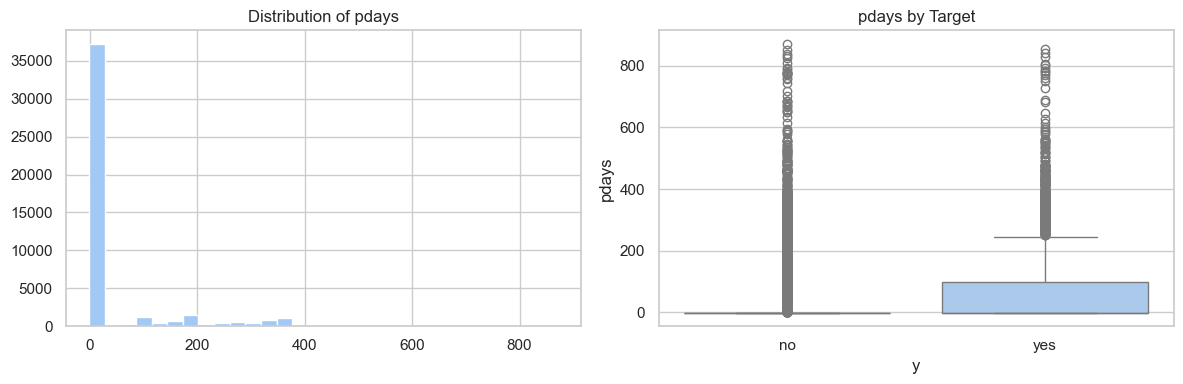


previous mean by target:
y
no     0.502154
yes    1.170354
Name: previous, dtype: float64


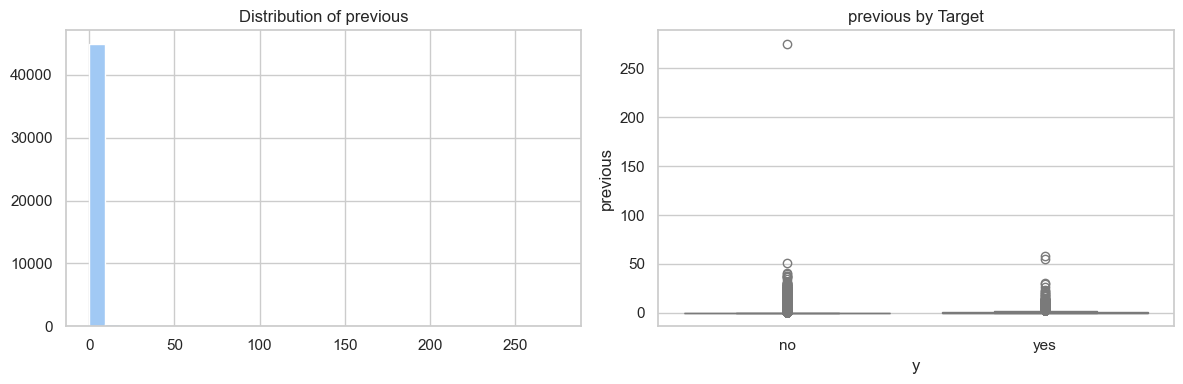

In [10]:
# For numeric features, compare distributions by target
for col in numeric_cols:
    print(f"\n{col} mean by target:")
    print(df.groupby("y")[col].mean())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution
    df[col].hist(ax=axes[0], bins=30)
    axes[0].set_title(f"Distribution of {col}")

    # Boxplot by target
    sns.boxplot(x="y", y=col, data=df, ax=axes[1])
    axes[1].set_title(f"{col} by Target")

    plt.tight_layout()
    plt.show()

- `Age`: Slightly higher average for customers who subscribed (yes: 41.7 vs no: 40.8).
- `Balance`: Customers who subscribed have notably higher balances on average (yes: 1,804 vs no: 1,304).
- `Day of Contact`: Mean day is similar for both groups (around day 15–16).
- `Duration`: Huge difference in call duration; subscribed customers had much longer calls (yes: 537 sec vs no: 221 sec). This suggests call duration is a strong indicator of subscription.
- `Campaign Attempts`: Fewer campaigns on average for subscribers (yes: 2.14 vs no: 2.85), indicating repeated contacts may not always convert.
- Days Since Last Contact (`pdays`): Higher mean for subscribers (yes: 68.7 vs no: 36.4), showing prior contact history may influence conversion.
- Previous Contacts (`previous`): Subscribers had more prior interactions on average (yes: 1.17 vs no: 0.50), reinforcing the importance of prior engagement.

**Insights:**
- `Duration`, `balance`, and `previous` interactions appear to have the strongest differences between the target classes.
- Some features (like `day`) show minimal separation.